# Online Shopping Behaviour: Leakage-Safe Purchase Intent Prediction

This notebook reproduces the final Project 10 analysis after the methodology audit. It does not use `added_to_cart`, `payment_method` or `rating` as model features because the supplied file does not prove that they are available before the prediction point.

In [1]:

from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

ROOT = Path.cwd()
OUT = ROOT / 'output' / 'online_shopping_capstone'
FIG = OUT / 'figures'
OUT.mkdir(parents=True, exist_ok=True)
FIG.mkdir(exist_ok=True)
DATA_PATH = ROOT / 'P_10_Ecommerce.csv'
df_raw = pd.read_csv(DATA_PATH)
df_raw.shape


(25000, 29)

## 1. Data Quality Audit and Cleaning

In [2]:

df = df_raw.copy()
print('Missing cells:', df.isna().sum().sum())
print('Exact duplicate rows:', df.duplicated().sum())
df['visit_date'] = pd.to_datetime(df['visit_date'], format='%d-%m-%Y')
df['pages_per_minute'] = np.where(df['time_on_site_sec'] > 0, df['pages_viewed'] / (df['time_on_site_sec'] / 60), 0)
df['discounted_unit_price'] = df['unit_price'] * (1 - df['discount_percent'] / 100)
df.to_csv(OUT / 'P10_Ecommerce_cleaned.csv', index=False)
df.head()


Missing cells: 0
Exact duplicate rows: 0


,customer_id,session_id,visit_date,device_type,user_type,marketing_channel,product_id,product_category,unit_price,quantity,...,payment_method,visit_day,visit_month,visit_weekday,visit_season,session_duration_bucket,revenue_normalized,location,pages_per_minute,discounted_unit_price
0,1803,0,2024-11-28,2,1,2,894,6,651.57,1,...,1,28,11,3,0,Long,0.000000,209,1.305699,521.2560
1,7964,1,2024-09-25,2,0,4,844,2,945.27,4,...,2,25,9,2,0,Long,0.000000,213,1.088083,803.4795
2,6890,2,2024-05-31,1,1,0,865,0,400.44,4,...,2,31,5,4,1,Short,0.000000,10,1.605634,400.4400
3,4949,3,2024-01-30,1,0,2,851,3,1268.54,2,...,1,30,1,1,3,Very Long,0.305504,46,0.681004,1205.1130
4,4896,4,2024-02-25,1,1,5,794,3,880.81,3,...,1,25,2,6,3,Very Short,0.000000,118,1.826698,880.8100


## 2. Leakage Audit

The prediction point is purchase-intent prediction before purchase completion. The supplied data do not include event timestamps showing that cart, payment or review-related fields are available before that point.

In [3]:

target = 'purchased'
cart_path_counts = (
    df.groupby(['added_to_cart', 'cart_abandoned', 'purchased'])
    .size().reset_index(name='rows')
    .sort_values(['added_to_cart', 'cart_abandoned', 'purchased'])
)
cart_path_counts


,added_to_cart,cart_abandoned,purchased,rows
0,0,0,0,8883
1,1,0,1,5616
2,1,1,0,10501


In [4]:

categorical = ['device_type','user_type','marketing_channel','product_category','visit_weekday','visit_month','visit_season','session_duration_bucket']
numeric = ['unit_price','discount_percent','pages_viewed','time_on_site_sec','pages_per_minute','discounted_unit_price']
features = categorical + numeric
excluded_features = {
    'added_to_cart': 'Not demonstrably available before the prediction point; cart path combinations encode the outcome.',
    'payment_method': 'Not demonstrably available before purchase intent prediction; usually collected during payment/checkout.',
    'rating': 'Not demonstrably available before purchase; usually post-experience/review data.',
    'revenue': 'Outcome transaction value.',
    'revenue_normalized': 'Derived from outcome transaction value.',
    'cart_abandoned': 'Reveals failed cart outcome.',
    'review_text': 'Post-purchase/post-experience content.',
    'review_helpful_votes': 'Post-review engagement.',
    'customer_id': 'Identifier.',
    'session_id': 'Identifier.',
    'product_id': 'High-cardinality identifier.',
    'quantity': 'Not demonstrated as final before prediction point.',
    'discount_amount': 'Redundant with retained price and discount fields.'
}
print('Final categorical:', categorical)
print('Final numeric:', numeric)


Final categorical: ['device_type', 'user_type', 'marketing_channel', 'product_category', 'visit_weekday', 'visit_month', 'visit_season', 'session_duration_bucket']
Final numeric: ['unit_price', 'discount_percent', 'pages_viewed', 'time_on_site_sec', 'pages_per_minute', 'discounted_unit_price']


## 3. Exploratory Analysis

In [5]:

print(df[target].value_counts())
print(df[target].value_counts(normalize=True).rename('proportion'))
print(df.groupby(target)[['pages_viewed','time_on_site_sec']].median())
channel_rate = df.groupby('marketing_channel')[target].mean().sort_values(ascending=False)
channel_rate


purchased
0    19384
1     5616
Name: count, dtype: int64
purchased
0    0.77536
1    0.22464
Name: proportion, dtype: float64
           pages_viewed  time_on_site_sec
purchased                                
0                  13.0             890.0
1                  13.0             942.5


marketing_channel
5    0.235984
0    0.227171
3    0.226433
1    0.221241
2    0.220276
4    0.216598
Name: purchased, dtype: float64

## 4. Preprocessing and Model Comparison

In [6]:

X, y = df[features], df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
preprocessor = ColumnTransformer([
    ('numeric', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scale', StandardScaler())]), numeric),
    ('categorical', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore'))]), categorical)
])
models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=300, min_samples_leaf=2, class_weight='balanced', random_state=42, n_jobs=-1)
}
results, fitted = {}, {}
for name, estimator in models.items():
    pipeline = Pipeline([('preprocessor', preprocessor), ('model', estimator)])
    pipeline.fit(X_train, y_train)
    prediction = pipeline.predict(X_test)
    probability = pipeline.predict_proba(X_test)[:, 1]
    results[name] = {
        'accuracy': float(accuracy_score(y_test, prediction)),
        'precision': float(precision_score(y_test, prediction, zero_division=0)),
        'recall': float(recall_score(y_test, prediction, zero_division=0)),
        'f1': float(f1_score(y_test, prediction, zero_division=0)),
        'roc_auc': float(roc_auc_score(y_test, probability)),
        'train_accuracy': float(accuracy_score(y_train, pipeline.predict(X_train))),
        'confusion_matrix': confusion_matrix(y_test, prediction).tolist()
    }
    fitted[name] = pipeline
results_df = pd.DataFrame(results).T
results_df


,accuracy,precision,recall,f1,roc_auc,train_accuracy,confusion_matrix
Logistic Regression,0.5384,0.265347,0.596616,0.367325,0.56739,0.5318,"[[2022, 1855], [453, 670]]"
Random Forest,0.729,0.266129,0.117542,0.163064,0.531633,0.9997,"[[3513, 364], [991, 132]]"


## 5. Final Evaluation

Selected model: Logistic Regression
accuracy                                0.5384
precision                             0.265347
recall                                0.596616
f1                                    0.367325
roc_auc                                0.56739
train_accuracy                          0.5318
confusion_matrix    [[2022, 1855], [453, 670]]
Name: Logistic Regression, dtype: object


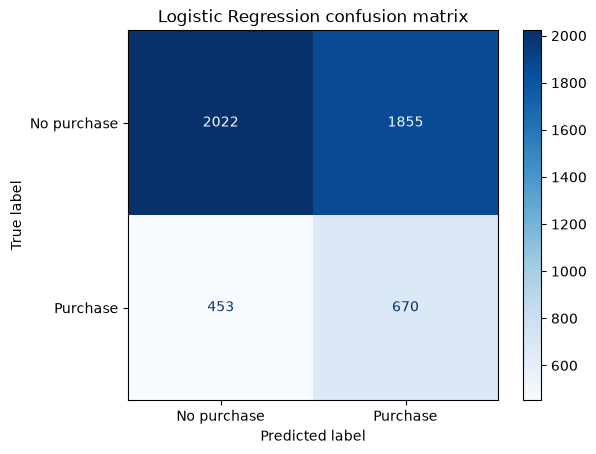

In [7]:

best_name = results_df['f1'].idxmax()
best_model = fitted[best_name]
best_prediction = best_model.predict(X_test)
print('Selected model:', best_name)
print(results_df.loc[best_name])
ConfusionMatrixDisplay.from_predictions(y_test, best_prediction, display_labels=['No purchase', 'Purchase'], cmap='Blues')
plt.title(f'{best_name} confusion matrix')
plt.show()


## 6. Feature Importance and Saved Outputs

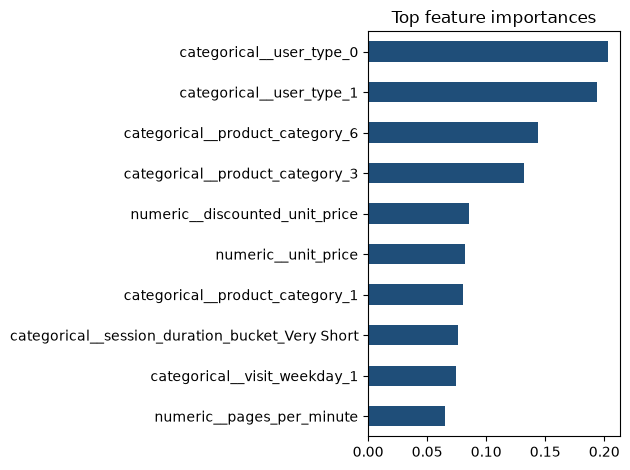

{'raw_rows': 25000,
 'raw_columns': 29,
 'missing_cells': 0,
 'duplicates': 0,
 'purchase_rate': 0.22464,
 'train_rows': 20000,
 'test_rows': 5000,
 'final_feature_list': {'categorical': ['device_type',
   'user_type',
   'marketing_channel',
   'product_category',
   'visit_weekday',
   'visit_month',
   'visit_season',
   'session_duration_bucket'],
  'numeric': ['unit_price',
   'discount_percent',
   'pages_viewed',
   'time_on_site_sec',
   'pages_per_minute',
   'discounted_unit_price'],
  'all': ['device_type',
   'user_type',
   'marketing_channel',
   'product_category',
   'visit_weekday',
   'visit_month',
   'visit_season',
   'session_duration_bucket',
   'unit_price',
   'discount_percent',
   'pages_viewed',
   'time_on_site_sec',
   'pages_per_minute',
   'discounted_unit_price']},
 'excluded_features': {'added_to_cart': 'Not demonstrably available before the prediction point; cart path combinations encode the outcome.',
  'payment_method': 'Not demonstrably available b

In [8]:

feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()
if best_name == 'Random Forest':
    importance = pd.Series(best_model.named_steps['model'].feature_importances_, index=feature_names)
else:
    # Logistic coefficients are signed; absolute magnitude ranks predictive contribution.
    importance = pd.Series(np.abs(best_model.named_steps['model'].coef_[0]), index=feature_names)
importance = importance.sort_values(ascending=False).head(10)
importance.to_frame('importance').rename_axis('feature').reset_index().to_csv(OUT / 'top_feature_importance.csv', index=False)
importance.sort_values().plot.barh(color='#1F4E79', title='Top feature importances')
plt.tight_layout()
plt.show()

summary = {
    'raw_rows': int(len(df_raw)),
    'raw_columns': int(len(df_raw.columns)),
    'missing_cells': int(df_raw.isna().sum().sum()),
    'duplicates': int(df_raw.duplicated().sum()),
    'purchase_rate': float(y.mean()),
    'train_rows': int(len(X_train)),
    'test_rows': int(len(X_test)),
    'final_feature_list': {'categorical': categorical, 'numeric': numeric, 'all': features},
    'excluded_features': excluded_features,
    'leakage_audit_result': {
        'decision': 'leakage_safe_after_feature_removal',
        'prediction_point': 'Purchase-intent prediction before purchase completion; no event timestamps prove checkout/cart/review fields are available.',
        'removed_not_demonstrably_pre_outcome': ['added_to_cart', 'payment_method', 'rating'],
        'added_to_cart_cart_path_counts': cart_path_counts.to_dict(orient='records')
    },
    'best_model': best_name,
    'results': results,
    'artifact_status': 'ready_for_submission_after_successful_rebuild'
}
(OUT / 'analysis_summary.json').write_text(json.dumps(summary, indent=2), encoding='utf-8')
summary
